# Module 6 - Cash Flow Forecasting

**Objective:** forecast weekly cash flow for the next 13 weeks using a recursive XGBoost time-series model.

The workflow aggregates transaction records to Monday-starting weeks, creates lag/calendar/rolling features using historical cash flow only, evaluates expanding-window 13-week forecasts every four weeks, compares XGBoost with a trailing-13-week mean baseline, and calibrates horizon-specific conformal prediction intervals from out-of-sample residuals. This design avoids using unknown future operating values as model inputs.

In [1]:
from pathlib import Path
import json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid', context='notebook')
SEED=42
HORIZON=13

def find_project_root(start=None):
    start=Path(start or Path.cwd()).resolve()
    for p in (start,*start.parents):
        if (p/'data'/'cleaned').is_dir() and (p/'Notebooks').is_dir(): return p
    raise FileNotFoundError('Project root not found. Open from the Project intership folder or set ROOT manually.')

ROOT=find_project_root()
preferred=ROOT/'data'/'cleaned'/'financials_cleaned.csv'
fallback=ROOT/'data'/'cleaned'/'financials_clean.csv'
DATA_PATH=preferred if preferred.exists() else fallback
if not DATA_PATH.exists(): raise FileNotFoundError(f'Dataset not found: {preferred} or {fallback}')
OUT=ROOT/'Reports'/'module6_cash_flow_forecasting'
FIG=OUT/'figures'; FIG.mkdir(parents=True,exist_ok=True)
df=pd.read_csv(DATA_PATH,parse_dates=['record_date'])
print(f'{len(df):,} records from {df.record_date.min().date()} to {df.record_date.max().date()}')

66,000 records from 2021-01-01 to 2024-12-31


## 1. Prepare historical weekly cash flow

In [2]:
df['week_start']=df.record_date-pd.to_timedelta(df.record_date.dt.weekday,unit='D')
weekly=df.groupby('week_start').agg(
    cash_flow_usd=('cash_flow_usd','sum'), revenue_usd=('revenue_usd','sum'),
    procurement_cost_usd=('procurement_cost_usd','sum'), logistics_cost_usd=('logistics_cost_usd','sum'),
    operational_cost_usd=('operational_cost_usd','sum'), sla_penalty_usd=('sla_penalty_usd','sum'),
    transactions=('finance_record_id','count')).sort_index()
calendar=pd.date_range(weekly.index.min(),weekly.index.max(),freq='W-MON')
weekly=weekly.reindex(calendar).rename_axis('week_start')
assert weekly.cash_flow_usd.notna().all(), 'Missing weekly cash flow after calendar reindexing.'
print(f'{len(weekly)} complete weeks; weekly cash flow range ${weekly.cash_flow_usd.min():,.0f} to ${weekly.cash_flow_usd.max():,.0f}')
display(weekly.head())

210 complete weeks; weekly cash flow range $-121,571,826 to $-7,155,276


,cash_flow_usd,revenue_usd,procurement_cost_usd,logistics_cost_usd,operational_cost_usd,sla_penalty_usd,transactions
week_start,,,,,,,
2020-12-28,-4.223467e+07,3375753.68,704522.23,89429.95,49782.02,141044.64,143
2021-01-04,-1.004339e+08,5783960.85,2379382.24,92470.25,118697.68,260684.75,333
2021-01-11,-7.083360e+07,6504290.95,1158727.25,83511.54,143124.28,334612.69,288
2021-01-18,-9.465748e+07,7122501.50,3678435.90,137828.50,118452.15,131639.92,328
2021-01-25,-7.374024e+07,7151075.52,2477488.91,109990.97,170834.21,215392.26,295


## 2. Lag, seasonal, and rolling feature engineering

In [3]:
LAGS=[1,2,3,4,8,13,26,52]
ROLLS=[4,13,26]

def make_features(history, dates):
    s=pd.Series(history,index=pd.DatetimeIndex(dates),dtype=float)
    f=pd.DataFrame(index=s.index)
    iso=f.index.isocalendar().week.astype(int)
    f['trend']=np.arange(len(f))
    f['week_sin']=np.sin(2*np.pi*iso/52.18); f['week_cos']=np.cos(2*np.pi*iso/52.18)
    f['month_sin']=np.sin(2*np.pi*f.index.month/12); f['month_cos']=np.cos(2*np.pi*f.index.month/12)
    for lag in LAGS: f[f'lag_{lag}']=s.shift(lag)
    for w in ROLLS:
        f[f'roll_mean_{w}']=s.shift(1).rolling(w).mean()
        f[f'roll_std_{w}']=s.shift(1).rolling(w).std(ddof=1)
        f[f'roll_min_{w}']=s.shift(1).rolling(w).min()
        f[f'roll_max_{w}']=s.shift(1).rolling(w).max()
    f['target']=s
    return f

features=make_features(weekly.cash_flow_usd.values,weekly.index).dropna()
FEATURES=[c for c in features if c!='target']
print(f'{len(FEATURES)} predictors; {len(features)} trainable weeks after lag warm-up')
display(features.head())

25 predictors; 158 trainable weeks after lag warm-up


,trend,week_sin,week_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_4,lag_8,...,roll_max_4,roll_mean_13,roll_std_13,roll_min_13,roll_max_13,roll_mean_26,roll_std_26,roll_min_26,roll_max_26,target
week_start,,,,,,,,,,,,,,,,,,,,,
2021-12-27,52,-0.021673,0.999765,-2.449294e-16,1.000000,-72874074.61,-55380312.68,-53450640.73,-72810195.07,-1.050034e+08,...,-53450640.73,-7.618915e+07,1.439520e+07,-1.050034e+08,-53450640.73,-8.002032e+07,1.327261e+07,-1.050034e+08,-53450640.73,-77951987.60
2022-01-03,53,0.120123,0.992759,5.000000e-01,0.866025,-77951987.60,-72874074.61,-55380312.68,-53450640.73,-8.793182e+07,...,-53450640.73,-7.613529e+07,1.438652e+07,-1.050034e+08,-53450640.73,-7.968614e+07,1.320848e+07,-1.050034e+08,-53450640.73,-82511393.69
2022-01-10,54,0.238506,0.971141,5.000000e-01,0.866025,-82511393.69,-77951987.60,-72874074.61,-55380312.68,-6.809061e+07,...,-55380312.68,-7.753320e+07,1.402305e+07,-1.050034e+08,-53450640.73,-7.932347e+07,1.298612e+07,-1.050034e+08,-53450640.73,-71997780.07
2022-01-17,55,0.353435,0.935459,5.000000e-01,0.866025,-71997780.07,-82511393.69,-77951987.60,-72874074.61,-7.741897e+07,...,-71997780.07,-7.705622e+07,1.410376e+07,-1.050034e+08,-53450640.73,-7.908062e+07,1.306460e+07,-1.050034e+08,-53450640.73,-83373465.92
2022-01-24,56,0.463246,0.886230,5.000000e-01,0.866025,-83373465.92,-71997780.07,-82511393.69,-77951987.60,-7.281020e+07,...,-71997780.07,-7.633566e+07,1.346026e+07,-1.050034e+08,-53450640.73,-7.875478e+07,1.283716e+07,-1.050034e+08,-53450640.73,-83487215.97


## 3. Train model and rolling-origin backtest

In [4]:
def new_model():
    return XGBRegressor(n_estimators=250,max_depth=3,learning_rate=.04,subsample=.85,
                        colsample_bytree=.85,reg_alpha=.15,reg_lambda=2.0,
                        objective='reg:squarederror',random_state=SEED,n_jobs=2)

def recursive_forecast(train_series, future_dates, model=None):
    hist=train_series.copy()
    if model is None:
        frame=make_features(hist.values,hist.index).dropna()
        model=new_model().fit(frame[FEATURES],frame.target)
    preds=[]
    for d in future_dates:
        extended=pd.concat([hist,pd.Series([np.nan],index=[d])])
        row=make_features(extended.values,extended.index).loc[[d],FEATURES]
        y=float(model.predict(row)[0]); preds.append(y); hist.loc[d]=y
    return np.array(preds),model

MIN_TRAIN_WEEKS=104
ORIGIN_STEP=4
origins=list(range(MIN_TRAIN_WEEKS,len(weekly)-HORIZON+1,ORIGIN_STEP))
if origins[-1] != len(weekly)-HORIZON:
    origins.append(len(weekly)-HORIZON)

backtests=[]
for fold,origin in enumerate(origins,1):
    train=weekly.cash_flow_usd.iloc[:origin]
    dates=weekly.index[origin:origin+HORIZON]
    pred,_=recursive_forecast(train,dates)
    baseline=np.repeat(train.tail(13).mean(),len(dates))
    actual=weekly.cash_flow_usd.loc[dates].values
    for h,(d,a,p,b) in enumerate(zip(dates,actual,pred,baseline),1):
        backtests.append({'fold':fold,'origin':train.index[-1],'horizon':h,'week_start':d,
                          'actual':a,'forecast':p,'baseline':b,'residual':a-p})
bt=pd.DataFrame(backtests)

def metric_row(name, actual, predicted):
    return {
        'Model':name,
        'RMSE_USD':mean_squared_error(actual,predicted)**.5,
        'MAE_USD':mean_absolute_error(actual,predicted),
        'MAPE_Pct':np.mean(np.abs((actual-predicted)/actual))*100
    }

metrics=pd.DataFrame([
    metric_row('XGBoost recursive',bt.actual,bt.forecast),
    metric_row('Trailing 13-week mean',bt.actual,bt.baseline)
])
rmse=float(metrics.loc[0,'RMSE_USD'])
mae=float(metrics.loc[0,'MAE_USD'])
mape=float(metrics.loc[0,'MAPE_Pct'])
baseline_mae=float(metrics.loc[1,'MAE_USD'])
mae_skill=1-mae/baseline_mae
display(metrics)
print(f'{len(origins)} rolling origins and {len(bt)} out-of-sample predictions')
print(f'XGBoost: RMSE USD {rmse:,.0f} | MAE USD {mae:,.0f} | MAPE {mape:.2f}% | MAE skill vs baseline {mae_skill:.1%}')

,Model,RMSE_USD,MAE_USD,MAPE_Pct
0,XGBoost recursive,1.698584e+07,1.312393e+07,19.989041
1,Trailing 13-week mean,1.513864e+07,1.165735e+07,18.515404


25 rolling origins and 325 out-of-sample predictions
XGBoost: RMSE USD 16,985,841 | MAE USD 13,123,928 | MAPE 19.99% | MAE skill vs baseline -12.6%


## 4. Actual versus forecast and residual diagnostics

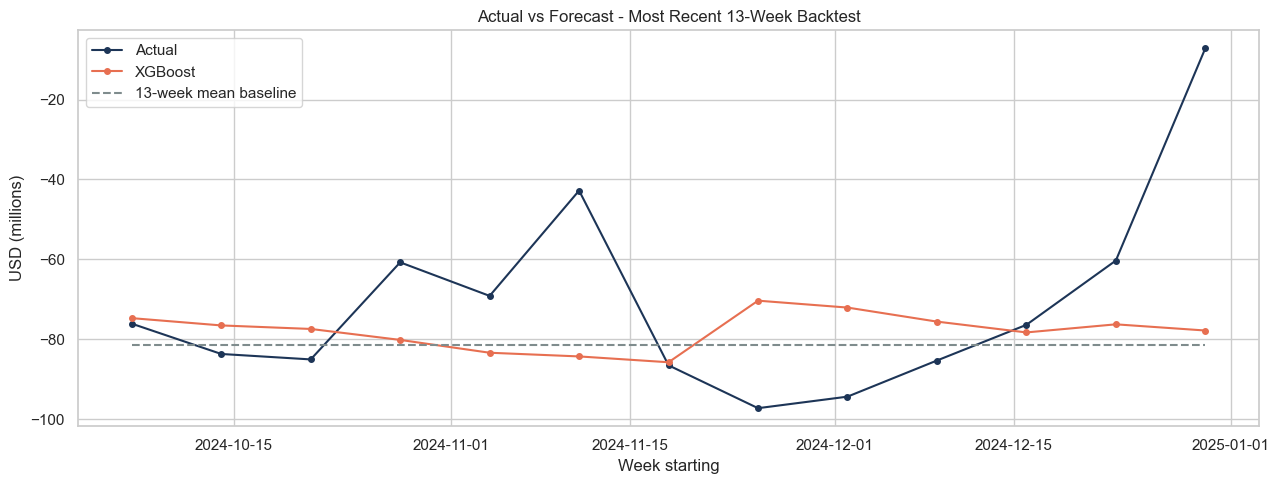

In [5]:
latest_bt=bt[bt.fold==bt.fold.max()].copy()
fig,ax=plt.subplots(figsize=(13,5))
ax.plot(latest_bt.week_start,latest_bt.actual/1e6,color='#1d3557',marker='o',ms=4,label='Actual')
ax.plot(latest_bt.week_start,latest_bt.forecast/1e6,color='#e76f51',marker='o',ms=4,label='XGBoost')
ax.plot(latest_bt.week_start,latest_bt.baseline/1e6,color='#7f8c8d',ls='--',label='13-week mean baseline')
ax.set(title='Actual vs Forecast - Most Recent 13-Week Backtest',xlabel='Week starting',ylabel='USD (millions)')
ax.legend(); fig.tight_layout(); fig.savefig(FIG/'01_actual_vs_forecast.png',dpi=180); plt.show()

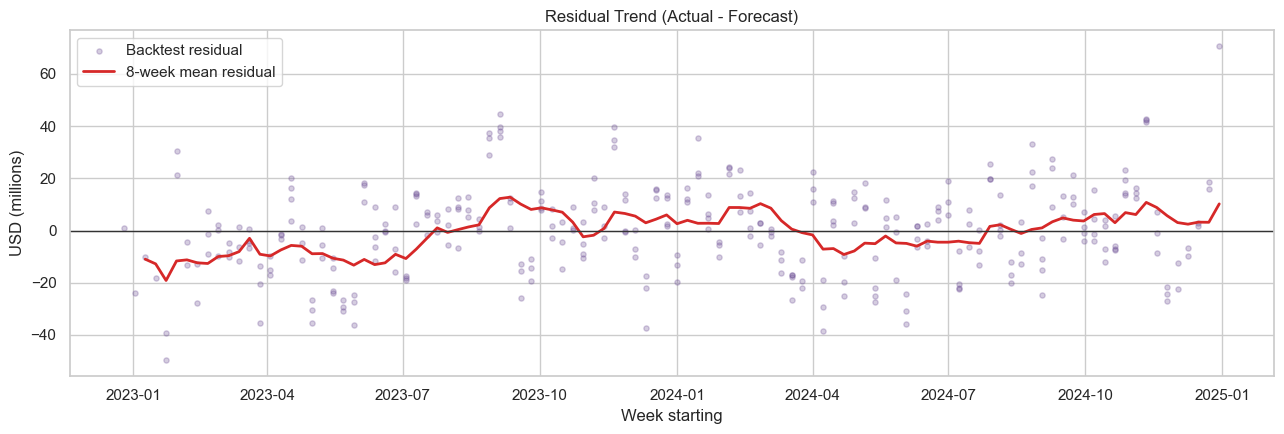

,mean,std,count
horizon,,,
1,-1.502506e+05,1.546167e+07,25
2,-2.332600e+06,1.297998e+07,25
3,-3.551272e+06,1.455666e+07,25
4,4.828231e+06,1.919744e+07,25
5,2.325118e+06,1.875580e+07,25
6,1.481602e+06,1.665471e+07,25
7,-1.703594e+06,1.766589e+07,25
8,2.948450e+06,2.035236e+07,25
9,-1.150167e+06,1.615827e+07,25


In [6]:
fig,ax=plt.subplots(figsize=(13,4.5))
ax.scatter(bt.week_start,bt.residual/1e6,color='#6a4c93',s=14,alpha=.28,label='Backtest residual')
resid_trend=bt.groupby('week_start').residual.mean().rolling(8,min_periods=3).mean()
ax.plot(resid_trend.index,resid_trend/1e6,color='#d62828',lw=2,label='8-week mean residual')
ax.axhline(0,color='#333',lw=1)
ax.set(title='Residual Trend (Actual - Forecast)',xlabel='Week starting',ylabel='USD (millions)')
ax.legend(); fig.tight_layout(); fig.savefig(FIG/'02_residual_trend.png',dpi=180); plt.show()
display(bt.groupby('horizon').residual.agg(['mean','std','count']))

## 5. Operational events associated with forecast error

In [7]:
bt_ops=bt.merge(weekly.reset_index(),on='week_start',how='left')
bt_ops['absolute_error']=bt_ops.residual.abs()
ops=['revenue_usd','procurement_cost_usd','logistics_cost_usd','operational_cost_usd','sla_penalty_usd','transactions']
event_assoc=[]
for c in ops:
    baseline=weekly[c].shift(1).rolling(13,min_periods=5).median().reindex(bt_ops.week_start).values
    bt_ops[c+'_deviation']=bt_ops[c]-baseline
    corr=bt_ops[['absolute_error',c+'_deviation']].corr(method='spearman').iloc[0,1]
    event_assoc.append({'event':c,'spearman_abs_error_correlation':corr})
event_assoc=pd.DataFrame(event_assoc).sort_values('spearman_abs_error_correlation',key=abs,ascending=False)
display(event_assoc)
print('Associations are diagnostic, not causal, and these operational values are not used as unknown future predictors.')

,event,spearman_abs_error_correlation
3,operational_cost_usd,0.219934
1,procurement_cost_usd,-0.106817
4,sla_penalty_usd,-0.080534
0,revenue_usd,0.065169
5,transactions,0.027811
2,logistics_cost_usd,-0.002444


Associations are diagnostic, not causal, and these operational values are not used as unknown future predictors.


## 6. Final 13-week forecast with conformal prediction intervals

In [8]:
def conformal_radius(values,coverage=.95):
    values=np.asarray(values,dtype=float)
    level=min(1.0,np.ceil((len(values)+1)*coverage)/len(values))
    return float(np.quantile(np.abs(values),level,method='higher'))

# Use early folds for interval calibration and later folds for an honest coverage check.
calibration_cut=int(np.floor(bt.fold.max()*.75))
cal_bt=bt[bt.fold<=calibration_cut]
eval_bt=bt[bt.fold>calibration_cut].copy()
cal_radii=cal_bt.groupby('horizon').residual.apply(conformal_radius).rename('radius_95')
eval_bt=eval_bt.join(cal_radii,on='horizon')
interval_coverage=float((eval_bt.residual.abs()<=eval_bt.radius_95).mean())

future_dates=pd.date_range(weekly.index[-1]+pd.Timedelta(weeks=1),periods=HORIZON,freq='W-MON')
point,final_model=recursive_forecast(weekly.cash_flow_usd,future_dates)
final_radii=bt.groupby('horizon').residual.apply(conformal_radius).reindex(range(1,HORIZON+1)).values
forecast=pd.DataFrame({
    'week_start':future_dates,
    'forecast_usd':point,
    'lower_95_usd':point-final_radii,
    'upper_95_usd':point+final_radii
})

# Risk is the empirical probability that a future week breaches the latest historical stress threshold.
stress_threshold=float(weekly.cash_flow_usd.tail(52).quantile(.10))
stress_prob=[]
for h,pred in enumerate(point,1):
    pool=bt.loc[bt.horizon==h,'residual'].values
    stress_prob.append(float(np.mean(pred+pool<=stress_threshold)))
forecast['stress_probability']=stress_prob
relative_cut=float(np.quantile(forecast.forecast_usd,.25))
forecast['treasury_attention']=(forecast.stress_probability>=.25) | (forecast.forecast_usd<=relative_cut)
attention_rule='stress probability >= 25% or point forecast in the lowest quartile'

display(forecast)
print(f'Validation coverage of nominal 95% intervals: {interval_coverage:.1%}')
print(f'Historical stress threshold: USD {stress_threshold:,.0f}')
print(f'Expected 13-week cumulative cash flow: USD {forecast.forecast_usd.sum():,.0f}')

,week_start,forecast_usd,lower_95_usd,upper_95_usd,stress_probability,treasury_attention
0,2025-01-06,-42274552.0,-8.194938e+07,-2599725.55,0.00,False
1,2025-01-13,-46893644.0,-7.725025e+07,-16537039.76,0.00,False
2,2025-01-20,-45574628.0,-7.284797e+07,-18301282.60,0.00,False
3,2025-01-27,-46078412.0,-8.200352e+07,-10153302.24,0.00,False
4,2025-02-03,-50061844.0,-9.983622e+07,-287466.40,0.04,True
5,2025-02-10,-48998684.0,-9.053387e+07,-7463498.68,0.00,True
6,2025-02-17,-47762488.0,-9.042063e+07,-5104350.68,0.00,True
7,2025-02-24,-45948492.0,-8.557269e+07,-6324289.54,0.00,False
8,2025-03-03,-47044088.0,-8.273405e+07,-11354125.55,0.00,False
9,2025-03-10,-43282600.0,-7.880082e+07,-7764385.00,0.00,False


Validation coverage of nominal 95% intervals: 94.5%
Historical stress threshold: USD -97,153,985
Expected 13-week cumulative cash flow: USD -611,798,412


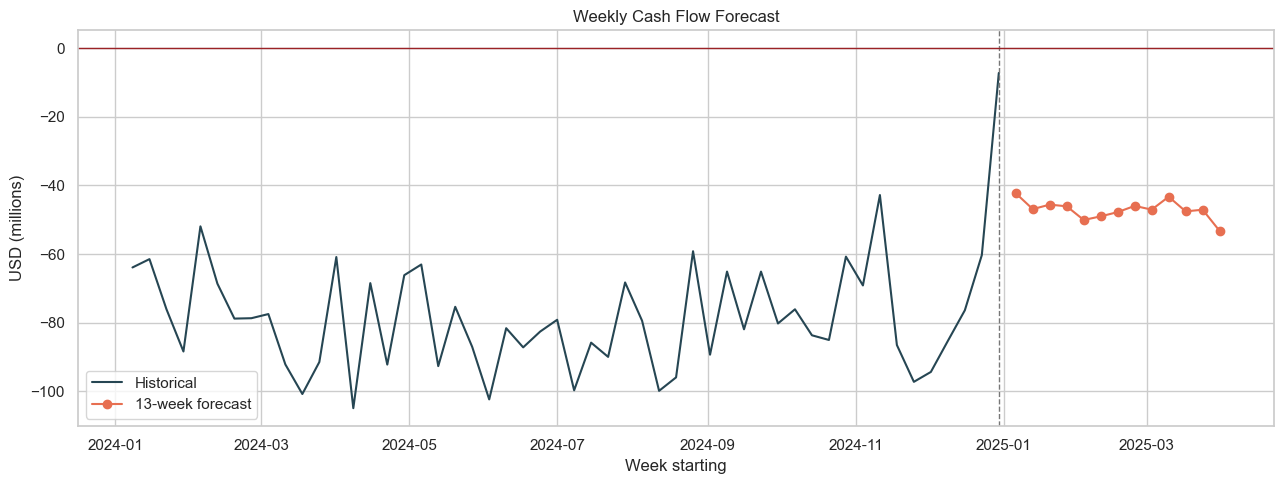

In [9]:
fig,ax=plt.subplots(figsize=(13,5))
hist=weekly.cash_flow_usd.tail(52)
ax.plot(hist.index,hist/1e6,color='#264653',label='Historical')
ax.plot(forecast.week_start,forecast.forecast_usd/1e6,color='#e76f51',marker='o',label='13-week forecast')
ax.axvline(weekly.index[-1],color='#777',ls='--',lw=1); ax.axhline(0,color='#9b2226',lw=1)
ax.set(title='Weekly Cash Flow Forecast',xlabel='Week starting',ylabel='USD (millions)'); ax.legend()
fig.tight_layout(); fig.savefig(FIG/'03_weekly_forecast.png',dpi=180); plt.show()

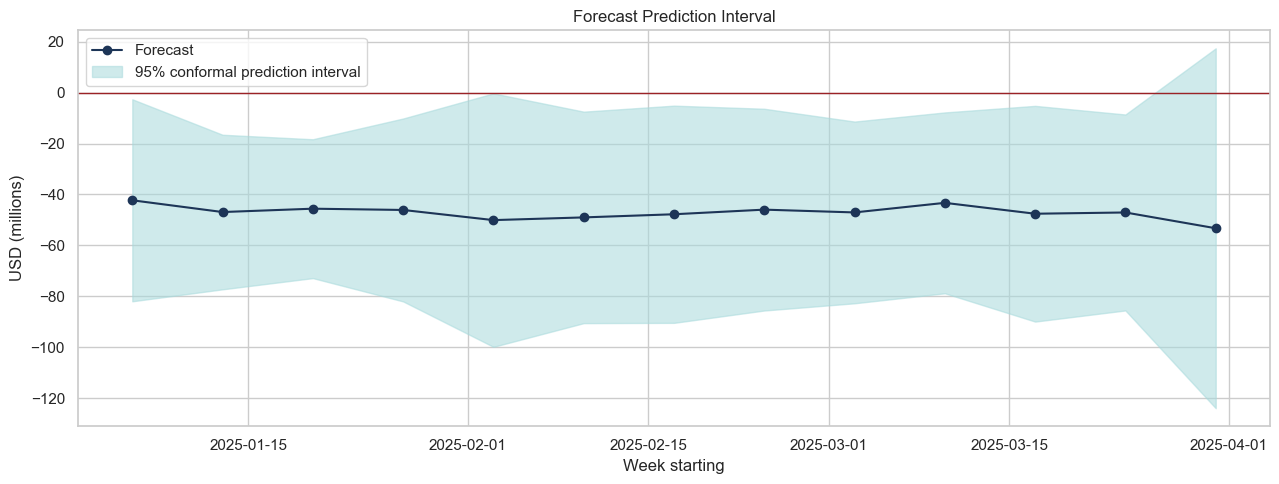

In [10]:
fig,ax=plt.subplots(figsize=(13,5))
ax.plot(forecast.week_start,forecast.forecast_usd/1e6,color='#1d3557',marker='o',label='Forecast')
ax.fill_between(forecast.week_start,forecast.lower_95_usd/1e6,forecast.upper_95_usd/1e6,color='#a8dadc',alpha=.55,label='95% conformal prediction interval')
ax.axhline(0,color='#9b2226',lw=1); ax.set(title='Forecast Prediction Interval',xlabel='Week starting',ylabel='USD (millions)'); ax.legend()
fig.tight_layout(); fig.savefig(FIG/'04_forecast_confidence_interval.png',dpi=180); plt.show()

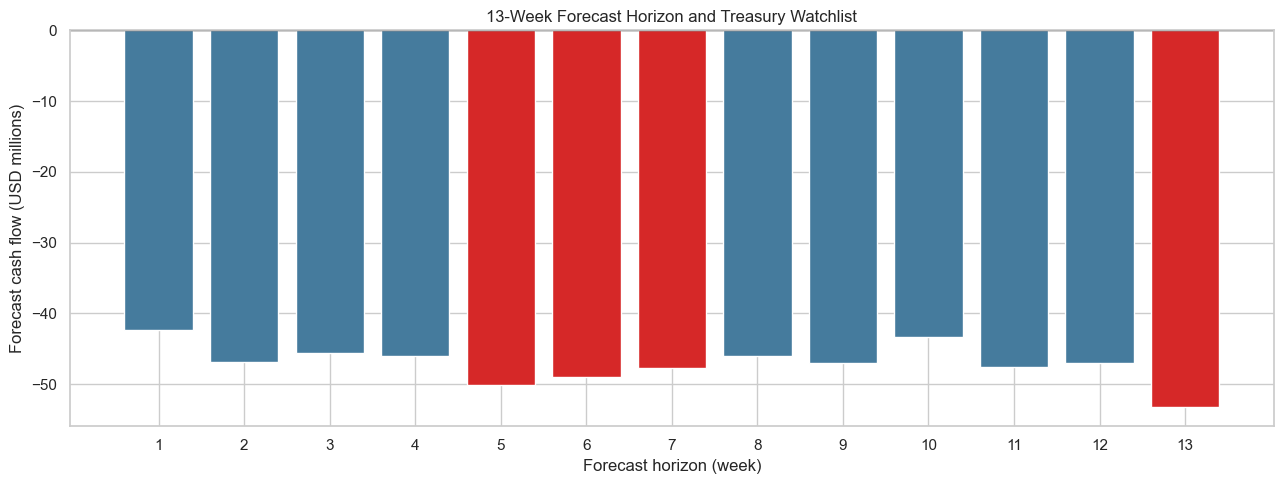

In [11]:
fig,ax=plt.subplots(figsize=(13,5))
colors=np.where(forecast.treasury_attention,'#d62828','#457b9d')
ax.bar(np.arange(1,HORIZON+1),forecast.forecast_usd/1e6,color=colors)
ax.axhline(0,color='#333',lw=1); ax.set(title='13-Week Forecast Horizon and Treasury Watchlist',xlabel='Forecast horizon (week)',ylabel='Forecast cash flow (USD millions)',xticks=np.arange(1,HORIZON+1))
fig.tight_layout(); fig.savefig(FIG/'05_forecast_horizon.png',dpi=180); plt.show()

## 7. Exports and executive answers

In [12]:
attention=forecast[forecast.treasury_attention]
summary={
    'history_weeks':int(len(weekly)),
    'forecast_horizon_weeks':HORIZON,
    'rolling_origins':int(len(origins)),
    'out_of_sample_predictions':int(len(bt)),
    'rmse_usd':rmse,
    'mae_usd':mae,
    'mape_pct':mape,
    'baseline_mae_usd':baseline_mae,
    'mae_skill_vs_baseline':float(mae_skill),
    'prediction_interval_validation_coverage':interval_coverage,
    'historical_stress_threshold_usd':stress_threshold,
    'attention_rule':attention_rule,
    'expected_13_week_cash_flow_usd':float(forecast.forecast_usd.sum()),
    'average_weekly_forecast_usd':float(forecast.forecast_usd.mean()),
    'lowest_forecast_week':str(forecast.loc[forecast.forecast_usd.idxmin(),'week_start'].date()),
    'lowest_week_forecast_usd':float(forecast.forecast_usd.min()),
    'attention_weeks':attention.week_start.dt.strftime('%Y-%m-%d').tolist(),
    'top_error_associations':event_assoc.head(3).to_dict('records')
}
print(json.dumps(summary,indent=2))
forecast.to_csv(OUT/'cash_flow_13_week_forecast.csv',index=False)
bt.to_csv(OUT/'rolling_backtest_predictions.csv',index=False)
metrics.to_csv(OUT/'forecast_evaluation_metrics.csv',index=False)
event_assoc.to_csv(OUT/'operational_event_error_associations.csv',index=False)
(OUT/'forecast_summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')

{
  "history_weeks": 210,
  "forecast_horizon_weeks": 13,
  "rolling_origins": 25,
  "out_of_sample_predictions": 325,
  "rmse_usd": 16985841.379858565,
  "mae_usd": 13123927.767723078,
  "mape_pct": 19.98904114406914,
  "baseline_mae_usd": 11657353.742016567,
  "mae_skill_vs_baseline": -0.12580677040111965,
  "prediction_interval_validation_coverage": 0.945054945054945,
  "historical_stress_threshold_usd": -97153985.045,
  "attention_rule": "stress probability >= 25% or point forecast in the lowest quartile",
  "expected_13_week_cash_flow_usd": -611798412.0,
  "average_weekly_forecast_usd": -47061416.307692304,
  "lowest_forecast_week": "2025-03-31",
  "lowest_week_forecast_usd": -53260732.0,
  "attention_weeks": [
    "2025-02-03",
    "2025-02-10",
    "2025-02-17",
    "2025-03-31"
  ],
  "top_error_associations": [
    {
      "event": "operational_cost_usd",
      "spearman_abs_error_correlation": 0.21993398071325052
    },
    {
      "event": "procurement_cost_usd",
      "spea

1169

### Business interpretation

- **Expected cash next quarter:** use the cumulative 13-week point forecast, together with the interval range; given the source sign convention, negative values represent forecast cash outflow/shortfall.
- **Treasury attention:** red horizon bars identify weeks with at least 25% empirical probability of breaching the historical stress threshold or a point forecast in the lowest quartile of the 13-week path. Use the lower prediction bound for downside liquidity planning.
- **Operational events:** the ranked correlations show which deviations coincide with large backtest errors. They are diagnostic associations, not causal estimates.

### Limitations

Only 210 weekly observations are available, and every historical weekly cash-flow aggregate is negative. The source should be reconciled to settled bank cash and sign conventions before funding decisions. Conformal intervals assume rolling-backtest residuals remain representative; their held-out coverage is reported. MAPE is reported because required, but MAE and RMSE are more dependable when actual values approach zero.